In [126]:
import os
import shutil
import subprocess
import json
import minizinc
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define the path to the dataset
dataset_path = 'dataset'

# Define the CSV file path
csv_file_path = 'dataset_summary.csv'

# Get the list of folders in the dataset directory
folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

# Open the CSV file for writing
with open(csv_file_path, mode='w', newline='') as csv_file:
    fieldnames = ['input.json', 'data.dzn', 'model.mzn', 'output.json']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    
    # Write the header
    writer.writeheader()
    
    # Iterate through each folder and add a row to the CSV
    for folder in folders:
        folder_path = os.path.join(dataset_path, folder)
        input_json_path = os.path.join(folder_path, 'input.json')
        output_json_path = os.path.join(folder_path, 'output.json')
        model_mzn_path = os.path.join(folder_path, "model.mzn")
        data_dzn_path = os.path.join(folder_path, "data.dzn")

        # Initialize row with file existence checks
        row = {
            'input.json': os.path.exists(input_json_path),
            'data.dzn': os.path.exists(data_dzn_path),
            'model.mzn': os.path.exists(model_mzn_path),
            'output.json': os.path.exists(output_json_path)
        }

        identifier = ""
        # Attempt to read identifier from input.json
        if row['input.json']:
            try:
                with open(input_json_path, 'r', encoding='utf-8') as json_file:
                    input_data = json.load(json_file)
                    for i in input_data['parameters']:
                        if "value" in i.keys():
                            i.pop('value')
                    if 'output' in input_data.keys():
                        for i in input_data['output']:
                            if "value" in i.keys():
                                i.pop('value')
                    with open(input_json_path, 'w') as fn:
                        json.dump(input_data, fn, indent=4)
                    

            except (json.JSONDecodeError, IOError) as e:
                print(f"Error reading {input_json_path}: {e}")
        identifier = input_data['metadata']['identifier']
        if (not(row["data.dzn"])):
            print("data not found for " + identifier)
        if (not(row["model.mzn"])):
            print("model not found for " + identifier)
        if (not(row["output.json"])):
            print("output not found for " + identifier)
        # Write the row to the CSV
        writer.writerow(row)


In [118]:
# Define the path to the dataset
dataset_path = 'dataset'

# Define the CSV file path
csv_file_path = 'dataset_summary.csv'

# Get the list of folders in the dataset directory
folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

# Open the CSV file for writing
with open(csv_file_path, mode='w', newline='') as csv_file:
    fieldnames = ['input.json', 'data.dzn', 'model.mzn', 'output.json']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    
    # Write the header
    writer.writeheader()
    
    problems = 0
    csplib = 0
    hakank = 0
    lpwp = 0
    nlp4lp = 0
    complexor = 0
    empty_models = 0
    objectives = {}
    domains = {}
    # Iterate through each folder and add a row to the CSV
    for folder in folders:
        problems += 1
        folder_path = os.path.join(dataset_path, folder)
        input_json_path = os.path.join(folder_path, 'input.json')
        output_json_path = os.path.join(folder_path, 'output.json')
        model_mzn_path = os.path.join(folder_path, "model.mzn")
        data_dzn_path = os.path.join(folder_path, "data.dzn")

        # Initialize row with file existence checks
        row = {
            'input.json': os.path.exists(input_json_path),
            'data.dzn': os.path.exists(data_dzn_path),
            'model.mzn': os.path.exists(model_mzn_path),
            'output.json': os.path.exists(output_json_path)
        }

        identifier = ""

        # Attempt to read identifier from input.json
        if row['input.json']:
            try:
                with open(input_json_path, 'r', encoding='utf-8') as json_file:
                    input_data = json.load(json_file)
                    identifier = input_data['metadata']['identifier']
                    
                    # Objectives
                    objective = input_data['metadata']['objective']
                    if objective not in objectives.keys():
                        objectives[objective] = 1
                    else:
                        objectives[objective] += 1
                    
                    # Domains
                    domain = input_data['metadata']['domain']
                    if domain not in domains.keys():
                        domains[domain] = 1
                    else:
                        domains[domain] += 1
                    
                    if identifier.startswith("CSPLib"):
                        csplib += 1
                    if identifier.startswith("nlp4lp"):
                        nlp4lp += 1
                    if identifier.startswith("LPWP"):
                        lpwp += 1
                    if identifier.startswith("complexor"):
                        complexor += 1


            except (json.JSONDecodeError, IOError) as e:
                print(f"Error reading {input_json_path}: {e}")
        identifier = input_data['metadata']['identifier']
        if (not(row["data.dzn"])):
            print("data not found for " + identifier)
        if (not(row["model.mzn"])):
            print("model not found for " + identifier)
        else:
            with open(model_mzn_path, 'r', encoding='utf-8') as model_file:
                first_line = model_file.readlines()[0].strip()  # Read all lines and get the first one
                if (first_line != "% Empty model file"):
                    empty_models += 1
        if (not(row["output.json"])):
            print("output not found for " + identifier)
        # Write the row to the CSV
        writer.writerow(row)

    print("CSPLib: " + str(csplib))
    print("NLP4LP: " + str(nlp4lp))
    print("LPWP: " + str(lpwp))
    print("ComplexOR: " + str(complexor))
    print("Total Problems: " + str(problems))
    print("Model Files: " + str(empty_models))
    print("Domains: " + str(domains))
    print(objectives)


CSPLib: 11
NLP4LP: 65
LPWP: 5
ComplexOR: 7
Total Problems: 110
Model Files: 45
Domains: {'Operations Research': 12, 'Industrial Engineering & Design': 3, 'Scheduling': 14, 'Economic and Business Decisions': 9, 'Puzzles and Games': 8, 'Manufacturing & Production': 19, 'Transportation & Logistics': 13, 'Mathematical Modeling': 13, 'Finance & Investment': 5, 'Energy and Natural Resources': 6, 'Healthcare & Human Systems': 5, 'Network and Security': 3}
{'minimization': 55, 'maximization': 45, 'satisfaction': 10}


In [113]:
domain_mapping = {
    "Operations Research": "Operations Research",
    "Optimization": "Operations Research",
    "Industrial Engineering": "Industrial Engineering & Design",
    "Scheduling": "Scheduling",
    "Economics": "Economic and Business Decisions",
    "Puzzles": "Puzzles and Games",
    "Manufacturing": "Manufacturing & Production",
    "Games and Puzzles": "Puzzles and Games",
    "Transportation": "Transportation & Logistics",
    "Linear Programming": "Mathematical Modeling",
    "Resource Allocation": "Scheduling",
    "Finance": "Finance & Investment",
    "Business": "Economic and Business Decisions",
    "Education": "Scheduling",
    "Combinatorial Mathematics": "Mathematical Modeling",
    "Workforce Scheduling": "Scheduling",
    "Design and Configuration": "Industrial Engineering & Design",
    "Mathematics": "Mathematical Modeling",
    "Logistics": "Transportation & Logistics",
    "Statistics": "Mathematical Modeling",
    "Physics": "Energy and Natural Resources",
    "Job Scheduling": "Scheduling",
    "Production Planning": "Manufacturing & Production",
    "Supply Chain Management": "Transportation & Logistics",
    "Energy": "Energy and Natural Resources",
    "Mining": "Energy and Natural Resources",
    "Investment Planning": "Finance & Investment",
    "Bin Packing and Partitioning": "Mathematical Modeling",
    "Advertising": "Economic and Business Decisions",
    "Human Resources": "Healthcare & Human Systems",
    "Healthcare": "Healthcare & Human Systems",
    "Network Optimization": "Network and Security",
    "Nutrition": "Healthcare & Human Systems",
    "Business Optimization": "Economic and Business Decisions",
    "Combinatorial Optimization": "Operations Research",
    "Integer Programming": "Operations Research",
    "Network Security": "Network and Security",
    "Auction Theory": "Economic and Business Decisions",
    "Marketing": "Economic and Business Decisions"
}

In [154]:
# Define the path to the dataset
dataset_path = 'dataset'

# Define the CSV file path
csv_file_path = 'dataset_summary.csv'

# Get the list of folders in the dataset directory
folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

# Open the CSV file for writing
with open(csv_file_path, mode='w', newline='') as csv_file:
    fieldnames = ['input.json', 'data.dzn', 'model.mzn', 'output.json']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    
    # Write the header
    writer.writeheader()
    
    problems = 0
    csplib = 0
    hakank = 0
    lpwp = 0
    nlp4lp = 0
    complexor = 0
    empty_models = 0
    objectives = {}
    domains = {}
    # Iterate through each folder and add a row to the CSV
    for folder in folders:
        problems += 1
        folder_path = os.path.join(dataset_path, folder)
        input_json_path = os.path.join(folder_path, 'input.json')
        output_json_path = os.path.join(folder_path, 'output.json')
        model_mzn_path = os.path.join(folder_path, "model.mzn")
        data_dzn_path = os.path.join(folder_path, "data.dzn")

        # Initialize row with file existence checks
        row = {
            'input.json': os.path.exists(input_json_path),
            'data.dzn': os.path.exists(data_dzn_path),
            'model.mzn': os.path.exists(model_mzn_path),
            'output.json': os.path.exists(output_json_path)
        }

        identifier = ""

        # Attempt to read identifier from input.json
        if row['input.json']:
            try:
                with open(input_json_path, 'r', encoding='utf-8') as json_file:
                    input_data = json.load(json_file)
                    identifier = input_data['metadata']['identifier']
                    # Objectives
                    objective = input_data['metadata']['objective']
                    if objective not in objectives.keys():
                        objectives[objective] = 1
                    else:
                        objectives[objective] += 1
                    
                    # Domains
                    domain = input_data['metadata']['domain']
                    if (domain == "Economic & Business Decisions"):
                        print(identifier)
                    if domain not in domains.keys():
                        domains[domain] = 1
                    else:
                        domains[domain] += 1
                    
                    # input_data['metadata']['domain'] = domain.replace("&", "and")
                    # print(input_data['metadata']['domain'])

                    if identifier.startswith("CSPLib"):
                        csplib += 1
                    if identifier.startswith("nlp4lp"):
                        nlp4lp += 1
                    if identifier.startswith("LPWP"):
                        lpwp += 1
                    if identifier.startswith("complexor"):
                        complexor += 1

                    #input_data['metadata']['domain'] = domain_mapping[input_data['metadata']['domain']]

                    # with open(input_json_path, 'w') as fn:
                    #     json.dump(input_data, fn, indent=4)

            except (json.JSONDecodeError, IOError) as e:
                print(f"Error reading {input_json_path}: {e}")
        identifier = input_data['metadata']['identifier']
        if (not(row["data.dzn"])):
            print("data not found for " + identifier)
        if (not(row["model.mzn"])):
            print("model not found for " + identifier)
        else:
            with open(model_mzn_path, 'r', encoding='utf-8') as model_file:
                first_line = model_file.readlines()[0].strip()  # Read all lines and get the first one
                if (first_line != "% Empty model file"):
                    empty_models += 1
        if (not(row["output.json"])):
            print("output not found for " + identifier)
        # Write the row to the CSV
        writer.writerow(row)

    print("CSPLib: " + str(csplib))
    print("NLP4LP: " + str(nlp4lp))
    print("LPWP: " + str(lpwp))
    print("ComplexOR: " + str(complexor))
    print("Total Problems: " + str(problems))
    print("Model Files: " + str(empty_models))
    print("Domains: " + str(domains))
    print(objectives)
    # Create bar plot
    


CSPLib: 11
NLP4LP: 65
LPWP: 5
ComplexOR: 7
Total Problems: 110
Model Files: 45
Domains: {'Transportation and Logistics': 16, 'Energy and Natural Resources': 7, 'Industrial Engineering and Design': 3, 'Scheduling': 14, 'Economic and Business Decisions': 12, 'Puzzles and Games': 8, 'Manufacturing and Production': 22, 'Mathematical Modeling': 15, 'Finance and Investment': 5, 'Healthcare and Human Systems': 5, 'Network and Security': 3}
{'minimization': 55, 'maximization': 45, 'satisfaction': 10}


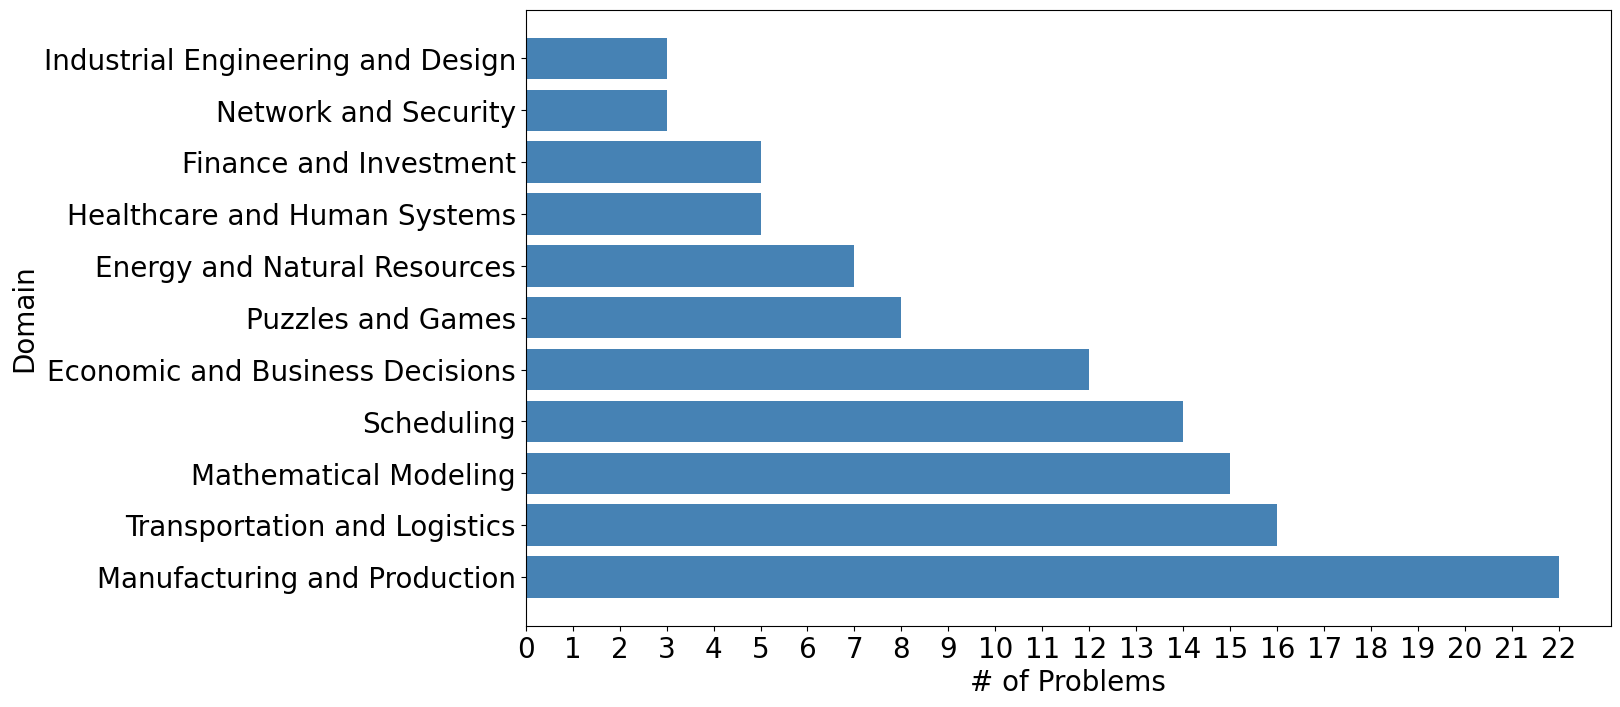

In [162]:
# Assuming 'domains' is defined
domain_counts = dict(sorted(domains.items(), key=lambda item: item[1]))

# Create bar plot with improved readability
plt.figure(figsize=(14, 8))  # Increase figure size
plt.barh(list(domain_counts.keys()), list(domain_counts.values()), color='steelblue')

# Set labels
plt.xlabel("# of Problems", fontsize=20)
plt.ylabel("Domain", fontsize=20)

# Ensure only integer values on x-axis
plt.xticks(np.arange(0, max(domain_counts.values()) + 1, 1), fontsize=20)

# Improve readability of y-axis labels
plt.yticks(fontsize=20)

# Invert y-axis to show highest values on top
plt.gca().invert_yaxis()

# Display the plot
plt.show()

In [219]:
import os
import json
import subprocess

# Define the source directory
source_dir = 'dataset'
solved = 0

# Iterate over each directory in the source directory
for dirname in os.listdir(source_dir):
    dir_path = os.path.join(source_dir, dirname)

    # Process only directories that start with "complexor"
    if not os.path.isdir(dir_path) or not dirname.startswith("complexor_CapacitatedWarehouseLocation"):
        continue

    # Iterate over the files in the directory
    for subdir in os.listdir(dir_path):
        if subdir.endswith('.dzn'):  # Check if the file is a .dzn file
            instance_path = os.path.join(dir_path, subdir)
            model_path = os.path.join(dir_path, 'model.mzn')
            output_path = os.path.join(dir_path, 'output.json')

            # Skip if output.json already contains a valid objective value
            if os.path.exists(output_path):
                with open(output_path, "r", encoding="utf-8") as file:
                    try:
                        output_vals = json.load(file)
                        if "_objective" in output_vals:
                            continue  # Skip if already solved
                        else:
                            print("Solving: ")
                            print(subdir)
                    except json.JSONDecodeError:
                        pass  # If file is corrupted, re-run MiniZinc

            if os.path.exists(model_path):
                try:
                    # Run MiniZinc with the "chuffed" solver in JSON output mode
                    result = subprocess.run(
                        ['minizinc', '--solver', 'highs', model_path, instance_path, '--output-objective', '--output-mode', 'json'],
                        capture_output=True, text=True
                    )

                    # Check if the process failed (non-zero exit code)
                    if result.returncode != 0:
                        print(f"Error solving {dirname}:")
                        print(result.stderr)  # Print the error message from MiniZinc
                        continue
                    
                    print(result)
                    #Extract JSON output
                    output = result.stdout.strip()
                    start = output.find('{')
                    end = output.rfind('}')
                    
                    if start != -1 and end != -1:
                        json_output = json.loads(output[start:end+1])
                    else:
                        print(json_output)
                        json_output = {"error": "Invalid MiniZinc output"}

                    # Save output to output.json
                    with open(output_path, 'w') as f:
                        json.dump(json_output, f, indent=4)

                    print(f"Solved: {dirname}")
                    solved += 1

                except json.JSONDecodeError:
                    print(f"Failed to parse JSON output for {dirname}")

            else:
                print(f"Missing model.mzn in {dirname}")

print(f"Total solved: {solved}")


Solving: 
data.dzn
CompletedProcess(args=['minizinc', '--solver', 'highs', 'dataset/complexor_CapacitatedWarehouseLocation/model.mzn', 'dataset/complexor_CapacitatedWarehouseLocation/data.dzn', '--output-objective', '--output-mode', 'json'], returncode=0, stdout='{\n  "WarehouseOpen" : [0, 0, 1, 0, 1, 0, 1, 0, 1, 0],\n  "CustomerAssignment" : [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],\n  "_objective" : 88241\n}\n-----

In [ ]:
# Remove the value key within for every parameter in input.json and for the variables specified in output.json


In [ ]:
# Rename the domains according to the table

In [3]:
# Port the dataset to a CSV

In [4]:
# Run Verification Scripts on the dataset

In [ ]:
# Dataset Statistics
# Bar chart of number of domains
# Count the number of satisfaction problems
# Count the non-linear constraints problems
# Count the constraint programming vs IP vs LP Problems. Idk really how to do that at the moment? Manually counted weird


In [ ]:
# Fix the categories

In [ ]:
# Generate a graph of the domains

In [76]:
# Count the problems in the dataset

In [ ]:
# Number of LP vs IP vs CP Problems in the dataset

In [73]:
# Validation Scripts:
#1. All folders have input.json, output.json, data.dzn, and sometimes a model.mzn

In [ ]:
# All folders have the correct keys in input.json

In [74]:
# The keys match in input.json and output.json

In [211]:
import os
import json

# Define the path to the nlp4lp directory
nlp4lp_path = 'nlp4lp'

# Define the path to the dataset directory
dataset_path = 'dataset'

# Iterate through each folder in the nlp4lp directory
for folder in os.listdir(nlp4lp_path):
    folder_path = os.path.join(nlp4lp_path, folder)
    
    # Check if the folder is a directory
    if os.path.isdir(folder_path):
        nlp4lp_obj_path = os.path.join(folder_path, 'obj.txt')
        dataset_output_path = os.path.join(dataset_path, 'nlp4lp_' + folder + '/output.json')

        # Check if the output.json file exists
        if os.path.exists(dataset_output_path):
            with open(dataset_output_path, 'r', encoding='utf-8') as json_file:
                print(dataset_output_path)
                output_data = json.load(json_file)
                print(output_data)
                # if os.path.exists(nlp4lp_obj_path):
                #     with open(nlp4lp_obj_path, 'r', encoding='utf-8') as dataf:
                #         obj = dataf
                #         obj_val = obj.readlines()[0]
                #         obj_to_output = float(obj_val.strip()[5:])
                # print(obj_to_output)
                # #output_data.pop("_objective")
                # output_data["_objective"] = obj_to_output
                # print(output_data)
                # print(output_data)
                # with open(dataset_output_path, 'w') as f:
                #         json.dump(output_data, f, indent=4)

                # # Extract the objective value
                # if 'OBJ' in output_data:
                #     obj_value = float(output_data['OBJ'])
                    
                #     # Create the new output.json content
                #     new_output_data = {"_objective": obj_value}
                    
                #     # Define the corresponding folder in the dataset directory
                #     dataset_folder_path = os.path.join(dataset_path, folder)
                    
                #     # Check if the corresponding folder exists in the dataset directory
                #     if os.path.exists(dataset_folder_path):
                #         new_output_json_path = os.path.join(dataset_folder_path, 'output.json')
                        
                #         # Write the new output.json file
                #         with open(new_output_json_path, 'w', encoding='utf-8') as new_json_file:
                #             json.dump(new_output_data, new_json_file, indent=4)

dataset/nlp4lp_61/output.json
{'_objective': 251500.0}
dataset/nlp4lp_66/output.json
{'_objective': 1256.0}
dataset/nlp4lp_50/output.json
{'_objective': 16620.0}
dataset/nlp4lp_57/output.json
{'_objective': 5600.0}
dataset/nlp4lp_32/output.json
{'_objective': 10.45}
dataset/nlp4lp_35/output.json
{'_objective': 1000.0}
dataset/nlp4lp_56/output.json
{'_objective': 33960.0}
dataset/nlp4lp_51/output.json
{'_objective': 178900.0}
dataset/nlp4lp_58/output.json
{'_objective': 5600.0}
dataset/nlp4lp_67/output.json
{'_objective': 45.0}
dataset/nlp4lp_60/output.json
{'_objective': 26.5}
dataset/nlp4lp_34/output.json
{'_objective': 986630.0}
dataset/nlp4lp_33/output.json
{'_objective': 1.475}
dataset/nlp4lp_20/output.json
{'_objective': 3000.0}
dataset/nlp4lp_18/output.json
{'_objective': 10305.11226}
dataset/nlp4lp_27/output.json
{'_objective': 10305.11226}
dataset/nlp4lp_9/output.json
{'_objective': 150.0}
dataset/nlp4lp_11/output.json
{'_objective': 240.9}
dataset/nlp4lp_7/output.json
{'_objec

In [ ]:
# {'_objective': '25150'}
# {'_objective': '125'}
# {'_objective': '1662'}
# {'_objective': '560'}
# {'_objective': '10.45'}
# {'_objective': '1.0e+0'}
# {'_objective': '3396'}{'_objective': '25150'}
# {'_objective': '125'}
# {'_objective': '1662'}
# {'_objective': '560'}
# {'_objective': '10.45'}
# {'_objective': '1.0e+0'}
# {'_objective': '3396'}
# {'_objective': '17890'}
# {'_objective': '560'}
# {'_objective': '4'}
# {'_objective': '26.5'}
# {'_objective': '986630'}
# {'_objective': '1.475'}
# {'_objective': '3000.0'}
# {'_objective': '1.030511226e+04'}
# {'_objective': '2619'}
# {'_objective': '150.0'}
# {'_objective': '240.9'}
# {'_objective': '0.011'}
# {'_objective': '2450'}
# {'_objective': '339000'}
# {'_objective': '15'}
# {'_objective': '9.0'}
# {'_objective': '0.11'}
# {'_objective': '2619'}
# {'_objective': '33900'}
# {'_objective': '78.64'}
# {'_objective': ' 7.3'}
# {'_objective': '107843.0'}
# {'_objective': '1.20e+04'}
# {'_objective': '93715.0'}
# {'_objective': '3'}
# {'_objective': '431433437.5'}
# {'_objective': '9.70e+02'}
# {'_objective': '20.0'}
# {'_objective': '19.95'}
# {'_objective': '228'}
# {'_objective': '712'}
# {'_objective': '70'}
# {'_objective': '975'}
# {'_objective': '14900'}
# {'_objective': '4.00'}
# {'_objective': '3.8e+03'}
# {'_objective': '1020'}
# {'_objective': '138'}
# {'_objective': '3500'}
# {'_objective': '29'}
# {'_objective': '62666.666666'}
# {'_objective': '450.0'}
# {'_objective': '10050'}
# {'_objective': '498677.0'}
# {'_objective': '1438383.0'}
# {'_objective': '1'}
# {'_objective': '654.'}
# {'_objective': '353.0'}
# {'_objective': '130'}
# {'_objective': '3710'}
# {'_objective': '1.20e+04'}
# {'_objective': '960'}
# {'_objective': '271250000'}
# {'_objective': '350.4'}
# {'_objective': '19'}
# {'_objective': '2.'}
# {'_objective': '93715.0'}
# {'_objective': '2142'}
# {'_objective': '17890'}
# {'_objective': '560'}
# {'_objective': '4'}
# {'_objective': '26.5'}
# {'_objective': '986630'}
# {'_objective': '1.475'}
# {'_objective': '3000.0'}
# {'_objective': '1.030511226e+04'}
# {'_objective': '2619'}
# {'_objective': '150.0'}
# {'_objective': '240.9'}
# {'_objective': '0.011'}
# {'_objective': '2450'}
# {'_objective': '339000'}
# {'_objective': '15'}
# {'_objective': '9.0'}
# {'_objective': '0.11'}
# {'_objective': '2619'}
# {'_objective': '33900'}
# {'_objective': '78.64'}
# {'_objective': ' 7.3'}
# {'_objective': '107843.0'}
# {'_objective': '1.20e+04'}
# {'_objective': '93715.0'}
# {'_objective': '3'}
# {'_objective': '431433437.5'}
# {'_objective': '9.70e+02'}
# {'_objective': '20.0'}
# {'_objective': '19.95'}
# {'_objective': '228'}
# {'_objective': '712'}
# {'_objective': '70'}
# {'_objective': '975'}
# {'_objective': '14900'}
# {'_objective': '4.00'}
# {'_objective': '3.8e+03'}
# {'_objective': '1020'}
# {'_objective': '138'}
# {'_objective': '3500'}
# {'_objective': '29'}
# {'_objective': '62666.666666'}
# {'_objective': '450.0'}
# {'_objective': '10050'}
# {'_objective': '498677.0'}
# {'_objective': '1438383.0'}
# {'_objective': '1'}
# {'_objective': '654.'}
# {'_objective': '353.0'}
# {'_objective': '130'}
# {'_objective': '3710'}
# {'_objective': '1.20e+04'}
# {'_objective': '960'}
# {'_objective': '271250000'}
# {'_objective': '350.4'}
# {'_objective': '19'}
# {'_objective': '2.'}
# {'_objective': '93715.0'}
# {'_objective': '2142'}


In [220]:
import os
import csv

# Define the path to the dataset
dataset_path = 'dataset'

# Define the CSV file path
csv_file_path = 'dataset_summary.csv'

# Get the list of folders in the dataset directory
folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

# Open the CSV file for writing
with open(csv_file_path, mode='w', newline='') as csv_file:
    fieldnames = ['input.json', 'data.dzn', 'model.mzn', 'output.json']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    
    # Write the header
    writer.writeheader()
    
    # Iterate through each folder and add a row to the CSV
    for folder in folders:
        folder_path = os.path.join(dataset_path, folder)
        input_json_path = os.path.join(folder_path, 'input.json')
        output_json_path = os.path.join(folder_path, 'output.json')
        model_mzn_path = os.path.join(folder_path, "model.mzn")
        data_dzn_path = os.path.join(folder_path, "data.dzn")
        
        # Initialize row with file existence checks
        row = {
            'input.json': os.path.exists(input_json_path),
            'data.dzn': os.path.exists(data_dzn_path),
            'model.mzn': os.path.exists(model_mzn_path),
            'output.json': os.path.exists(output_json_path)
        }

        with open(input_json_path, 'r', encoding='utf-8') as json_file:
            input_data = json.load(json_file)
            row['input.json'] = json.dumps(input_data)
        
        with open(output_json_path, 'r', encoding='utf-8') as json_file:
            output_data = json.load(json_file)
            row['output.json'] = json.dumps(output_data)
        
        with open(model_mzn_path, 'r', encoding='utf-8') as model_file:
            model_data = model_file.read()
            row['model.mzn'] = model_data

        with open(data_dzn_path, 'r', encoding='utf-8') as data_file:
            data_data = data_file.read()
            row['data.dzn'] = data_data

        

        # Write the row to the CSV
        writer.writerow(row)

In [132]:
import csv

# Define the CSV file path
csv_file_path = 'dataset_summary.csv'

# Read the CSV file and convert it into a list of dictionaries
with open(csv_file_path, mode='r', newline='') as csv_file:
    reader = csv.DictReader(csv_file)
    data_list = [row for row in reader]

print(reader[0])
# Print the unpacked data
for data in data_list:
    print(data)

TypeError: 'DictReader' object is not subscriptable

In [133]:
import os
import csv
import json

# Define the base directory for reconstruction
dataset_path = 'reconstructed_dataset'
csv_file_path = 'dataset_summary.csv'

# Create the base dataset directory if it doesn't exist
os.makedirs(dataset_path, exist_ok=True)

# Open and read the CSV file
with open(csv_file_path, mode='r', encoding='utf-8') as csv_file:
    reader = csv.DictReader(csv_file)

    # Iterate through each row and reconstruct the folder structure
    for idx, row in enumerate(reader):
        # Create a unique folder for each row
        folder_name = f"folder_{idx+1}"
        folder_path = os.path.join(dataset_path, folder_name)
        os.makedirs(folder_path, exist_ok=True)

        # Write each file if it contains valid content
        for file_name, content in row.items():
            if content:  # Ensure content exists
                file_path = os.path.join(folder_path, file_name)
                if file_name.endswith('.json'):
                    # Save JSON files properly formatted
                    with open(file_path, 'w', encoding='utf-8') as json_file:
                        json.dump(json.loads(content), json_file, indent=4)
                else:
                    # Save text-based files (.mzn, .dzn)
                    with open(file_path, 'w', encoding='utf-8') as text_file:
                        text_file.write(content)

print("Dataset reconstruction complete!")


Dataset reconstruction complete!
